In [12]:
import os
from time import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, gaussian_filter

import chromatix.functional as cx
from chromatix.ops import init_plane_resample
from chromatix.field import crop, pad

import jax
from jax import Array
import jax.numpy as jnp
from jax.scipy.ndimage import map_coordinates

from flax import linen as nn
from flax.core import unfreeze, freeze

# from xpc.transformations import rotate_volume

In [8]:
os.chdir('..')
from inputs.phantom.phantom_helpers import phantom_crop_xy, phantom_upsample
from src.xpc.xscatter import get_wavelen, nist_mc, Material, apply_psf

os.chdir('multislice')

In [9]:
OsO4_01 = Material(
            'osmium tetroxide',  # mix 1% osmium tetroxide in water
             density = 1.007943,
             matcomp = 'H(1.8983)O(35.9582)Os(62.1435)'
        )

UA_01 = Material(
            'uranium acetate',  # mix 1% uranyl acetate in water,
             density = 1.006517,
             matcomp = 'H(4.6446)C(8.4146)N(45.248)U(41.6928)'
        )

Water = Material(
            'water',
             density = 1.0,
             matcomp = nist_mc['Water, Liquid']
        )

Adipose = Material(
            'adipose',
             density = 0.95,
             matcomp = nist_mc['Adipose Tissue (ICRU-44)'],
        )
Tissue = Material(
            'tissue',
             density = 1.06,
             matcomp = nist_mc['Tissue, Soft (ICRU-44)']
    )

Wax = Material(
            'paraffin wax',
             density = 0.90,
             matcomp = 'H(0.147674)C(0.852326)'  # C31H64
    )

In [4]:
def get_roi(img, p=0.05, c=0.5):
    Nx = img.shape[0]
    N1 = int(c*Nx)
    N2 = N1 + int(p*Nx)
    return img[N1:N2, N1:N2]
    
def imshow_and_roi(img, c=0.34, p=0.07, figsize=[10,4], kw={}, boxcolor='r'):
    
    Nx = img.shape[0]
    N1 = int(c*Nx)
    N2 = N1 + int(p*Nx)
    
    fig, ax = plt.subplots(1, 2, figsize=figsize, layout='constrained')

    for i in range(2):
        M = [ img, img[N1:N2, N1:N2] ][i]
        label = ['Full image', rf'{100*p:.0f}% FOV region'][i]
        m = ax[i].imshow(M, **kw)
        fig.colorbar(m, ax=ax[i])
        ax[i].set_title(label)

    # draw ROI 
    xbox = [N1, N1, N2, N2, N1]
    ybox = [N1, N2, N2, N1, N1]
    ax[0].plot(xbox, ybox, '-', color=boxcolor)
    
    plt.show()

# imshow_and_roi(raw_fish)

In [13]:
def R2(theta: float, dtype=jnp.float32) -> jnp.ndarray:
    """Generates 2D rotation matrix.
    Theta in radians."""
    R = jnp.zeros((3, 3), dtype=dtype)
    sin_t = jnp.sin(theta).astype(dtype)
    cos_t = jnp.cos(theta).astype(dtype)

    R = R.at[2, 2].set(1.0)  # homogeneous
    R = R.at[0, 0].set(cos_t)
    R = R.at[0, 1].set(-sin_t)
    R = R.at[1, 0].set(sin_t)
    R = R.at[1, 1].set(cos_t)

    return R


def image_homogeneous_grid(image: Array) -> Array:
    """Given an image, generates a centred grid of homogeneous coordinates.
    Coordinates are placed along last dimension [y, x, 3]"""

    Ny, Nx = image.shape
    y = jnp.linspace(-(Ny - 1) / 2, (Ny - 1) / 2, Ny, dtype=image.dtype)
    x = jnp.linspace(-(Nx - 1) / 2, (Nx - 1) / 2, Nx, dtype=image.dtype)
    grid = jnp.stack(jnp.meshgrid(y, x, indexing='ij'), axis=-1)
    return jnp.concatenate(
        [grid, jnp.ones((Ny, Nx, 1), dtype=image.dtype)], axis=-1
    )

def resample_image(image: Array, sample_grid: Array, cval: float = 0.0) -> Array:
    """Resample image on coordinates given by grid.
    Assumes original coordinates were centered, i.e. -N/2 -> N/2"""
    offset = (jnp.array(image.shape) - 1) / 2
    sample_locations = sample_grid.reshape(-1, 2).T + offset[:, None]
    resampled = map_coordinates(
        image, list(sample_locations), order=1, mode='constant', cval=cval
    )
    return resampled.reshape(sample_grid.shape[:2])


def rotate_image(image: Array, angle: float, cval: float = 0.0) -> Array:
    """Rotates an image in the y-x plane about its center.
    angle in radians."""
    rotated_grid = image_homogeneous_grid(image) @ R2(angle, image.dtype).T
    return resample_image(image, rotated_grid[..., :2], cval=cval)
from jax import Array
import jax.numpy as jnp


def segment_project_slices(image: Array, Nz: int, dz: float) -> Array:
    """Collapse a 2D rotated image into Nz partial z-projections.

    Parameters
    ----------
    image : Array, shape (Ny, Nx)
        Rotated image to be projected along axis 0 (y).
    Nz : int
        Number of projection slices to generate.
    dx : float
        Pixel size / path-length increment along the projection axis.

    Returns
    -------
    proj_slices : Array, shape (Nz, Nx)
        Partial projections whose sum over axis 0 equals the full projection.
    """
    Ny, Nx = image.shape
    edges = jnp.linspace(0, Ny, Nz + 1)
    edges = jnp.round(edges).astype(jnp.int32)

    proj_slices = jnp.stack([
        image[edges[i]:edges[i + 1]].sum(axis=0)
        for i in range(Nz)
    ], axis=0)

    return dz * proj_slices

In [17]:
def R2(theta: float, dtype=jnp.float32) -> jnp.ndarray:
    """Generate a 2D homogeneous rotation matrix.

    Parameters
    ----------
    theta : float
        Rotation angle in radians.
    dtype : dtype, optional
        Output dtype.

    Returns
    -------
    R : jnp.ndarray, shape (3, 3)
        Homogeneous rotation matrix.
    """
    sin_t = jnp.sin(theta).astype(dtype)
    cos_t = jnp.cos(theta).astype(dtype)

    return jnp.array([
        [cos_t, -sin_t, 0.0],
        [sin_t,  cos_t, 0.0],
        [0.0,    0.0,   1.0],
    ], dtype=dtype)


def image_homogeneous_grid_from_shape(shape, dtype=jnp.float32) -> Array:
    """Generate a centered grid of homogeneous image coordinates.

    Parameters
    ----------
    shape : tuple
        Image shape (Ny, Nx).
    dtype : dtype, optional
        Grid dtype.

    Returns
    -------
    grid : Array, shape (Ny, Nx, 3)
        Centered homogeneous coordinates with last axis [y, x, 1].
    """
    Ny, Nx = shape
    y = jnp.linspace(-(Ny - 1) / 2, (Ny - 1) / 2, Ny, dtype=dtype)
    x = jnp.linspace(-(Nx - 1) / 2, (Nx - 1) / 2, Nx, dtype=dtype)
    grid = jnp.stack(jnp.meshgrid(y, x, indexing='ij'), axis=-1)

    return jnp.concatenate(
        [grid, jnp.ones((Ny, Nx, 1), dtype=dtype)],
        axis=-1
    )


def resample_image(image: Array, sample_grid: Array, cval: float = 0.0) -> Array:
    """Resample image on centered coordinates given by sample_grid.

    Parameters
    ----------
    image : Array, shape (Ny, Nx)
        Input image.
    sample_grid : Array, shape (Ny, Nx, 2)
        Sampling coordinates in centered [y, x] convention.
    cval : float, optional
        Constant fill value outside the image.

    Returns
    -------
    resampled : Array, shape (Ny, Nx)
        Resampled image.
    """
    offset = (jnp.array(image.shape, dtype=image.dtype) - 1) / 2
    sample_locations = sample_grid.reshape(-1, 2).T + offset[:, None]

    resampled = map_coordinates(
        image,
        list(sample_locations),
        order=1,
        mode='constant',
        cval=cval
    )

    return resampled.reshape(sample_grid.shape[:2])


def rotate_image_from_grid(
    image: Array,
    base_grid: Array,
    angle: float,
    cval: float = 0.0
) -> Array:
    """Rotate an image in the y-x plane about its center.

    Parameters
    ----------
    image : Array, shape (Ny, Nx)
        Input image.
    base_grid : Array, shape (Ny, Nx, 3)
        Precomputed centered homogeneous coordinate grid.
    angle : float
        Rotation angle in radians.
    cval : float, optional
        Constant fill value outside the image.

    Returns
    -------
    rotated : Array, shape (Ny, Nx)
        Rotated image.
    """
    rotated_grid = base_grid @ R2(angle, image.dtype).T
    return resample_image(image, rotated_grid[..., :2], cval=cval)


def segment_project_slices(image: Array, Nz: int, dx: float) -> Array:
    """Collapse a 2D rotated image into Nz partial projections.

    The image is projected along axis 0 (y), split into Nz contiguous
    blocks, and summed within each block.

    Parameters
    ----------
    image : Array, shape (Ny, Nx)
        Rotated image to be projected along axis 0.
    Nz : int
        Number of partial projection slices to generate.
    dx : float
        Pixel size / path-length increment along the projection axis.

    Returns
    -------
    proj_slices : Array, shape (Nz, Nx)
        Partial projections whose sum over axis 0 equals the full
        projected thickness/profile.
    """
    Ny, Nx = image.shape

    rows_per_bin = (Ny + Nz - 1) // Nz
    Ny_pad = rows_per_bin * Nz
    pad_rows = Ny_pad - Ny

    image_pad = jnp.pad(image, ((0, pad_rows), (0, 0)))
    proj_slices = image_pad.reshape(Nz, rows_per_bin, Nx).sum(axis=1)

    return dx * proj_slices

# Read and upsample fish

In [6]:
def slice_upsample_labels(vol, dx, dx0, k_blur=1, thresh=0.35):
    """
    Default pars tuned for zebrafish.
    """
    
    Ny0, Nx0 = vol.shape
    Nx = int(round(Nx0 * dx0 / dx))
    Ny = int(round(Ny0 * dx0 / dx))
    
    best_score = np.full([Ny, Nx], -np.inf, dtype=np.float32)
    label_img = np.zeros([Ny, Nx], dtype=np.uint8)  # the upsampled phantom!
    
    for m in np.unique(vol[vol > 0]):
    
        sigma = k_blur * dx0 / dx
        pad = int(np.ceil(k_blur))
    
        mask = vol == m
        up_mask = zoom(mask, (Nx/Nx0, Ny/Ny0), order=0)
        
        blur = gaussian_filter(up_mask.astype(np.float32), sigma=sigma)  # temp convert to float
        score = blur - thresh
    
        # update the phantom
        score_view = best_score 
        label_view = label_img  
    
        update = score > score_view
        update &= score > 0
    
        score_view[update] = score[update]
        label_view[update] = m
    
    return label_img

0


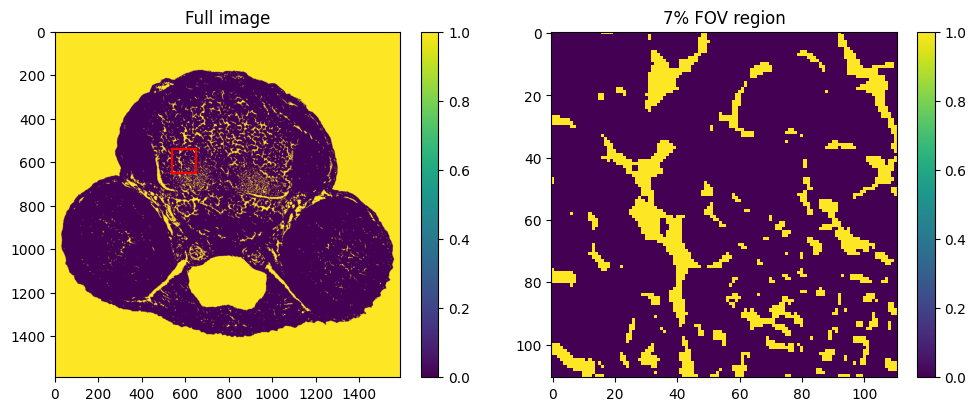

1


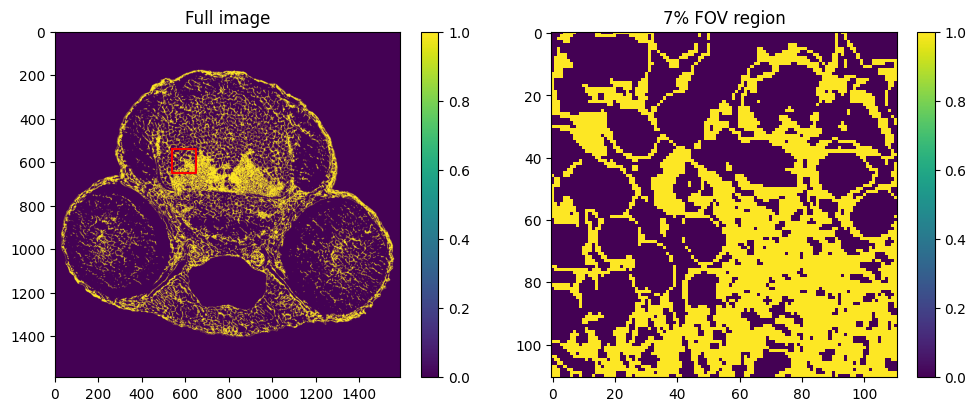

12


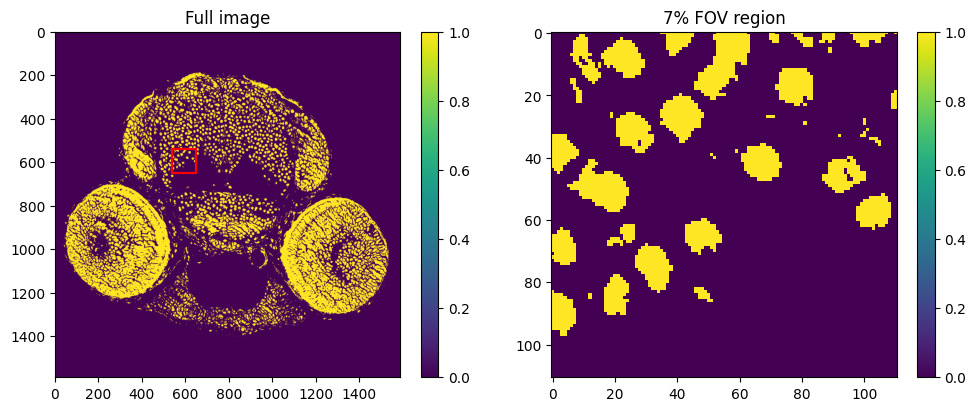

13


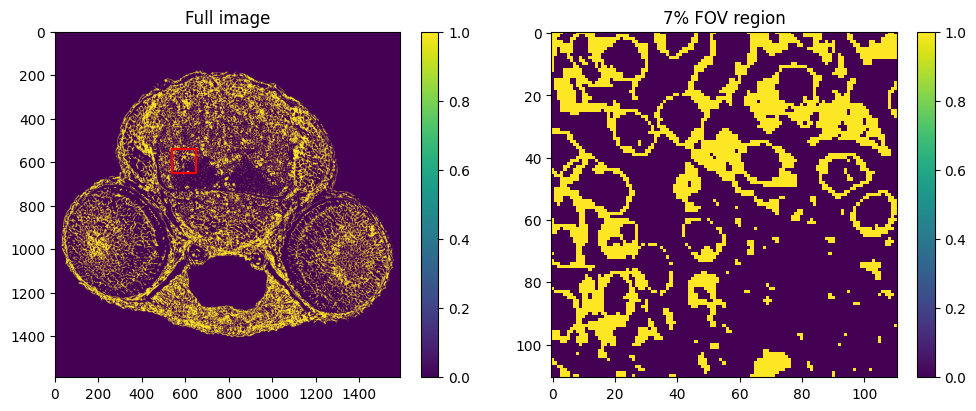

In [5]:
Nx0 = 1590  
dx0 = 1.4e-6
raw_fish = np.fromfile(
    '../inputs/phantom/zebrafish_2D/zebrafish_1590_1590_4mat_uint8.bin',
    dtype=np.uint8).reshape([Nx0, Nx0])

for m in np.unique(raw_fish):
    print(m)
    imshow_and_roi(raw_fish==m)

(1590, 1590)
(11130, 11130)
0


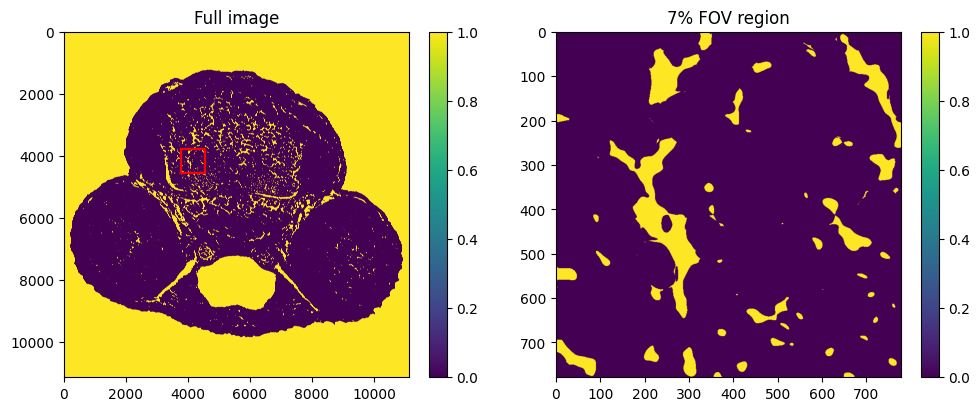

1


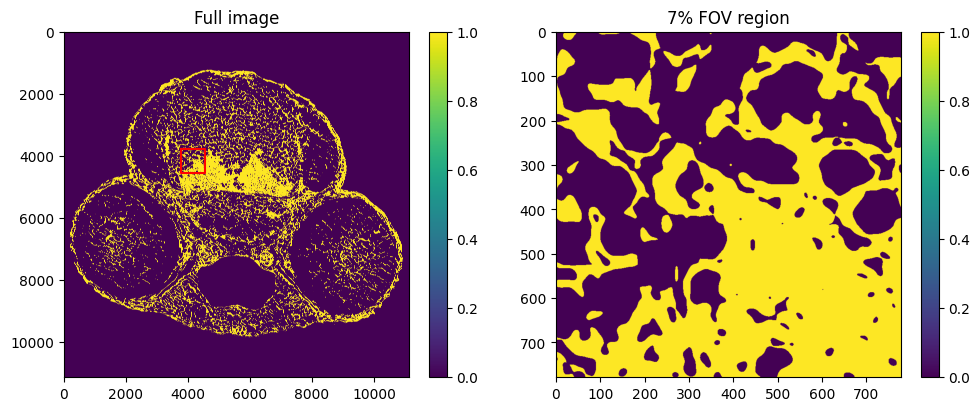

12


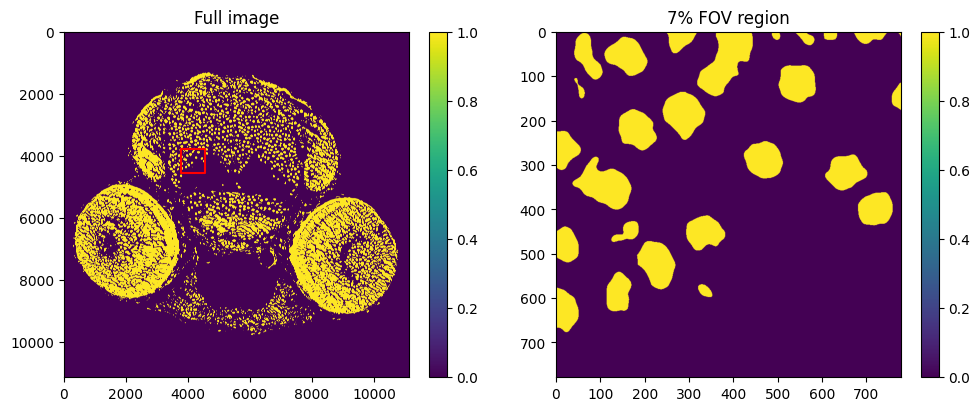

13


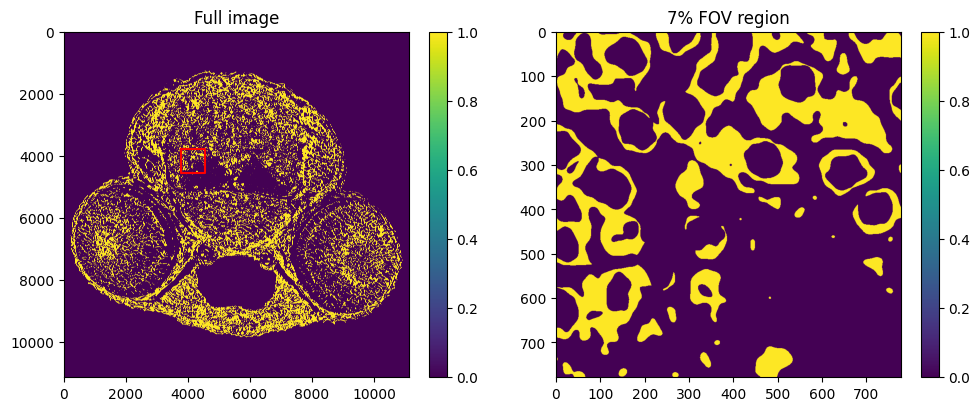

CPU times: user 42.2 s, sys: 13.6 s, total: 55.8 s
Wall time: 56.4 s


In [15]:
%%time
print(raw_fish.shape)

up_fish = slice_upsample_labels(
    vol=raw_fish, #[400:800, 400:800], 
    dx=0.2e-6, 
    dx0=1.4e-6
)

print(up_fish.shape)

for m in np.unique(up_fish):
    print(m)
    imshow_and_roi(up_fish==m)

# Simulate sashimi projections

In [10]:
def label_to_db_phantom(label_phantom, matdict, energy, dtype=np.float32, skip_zero=True):
    Ny, Nx = label_phantom.shape
    db_phantom = np.zeros([Ny, Nx, 2], dtype=dtype)
    mat_ids = np.unique(label_phantom)
    if skip_zero:
        mat_ids = mat_ids[mat_ids > 0]
    for idx in mat_ids:
        mat = matdict[idx]
        delta, beta = mat.delta_beta(energy)
        db_phantom[:,:,0][label_phantom == idx] = beta
        db_phantom[:,:,1][label_phantom == idx] = delta
    return db_phantom

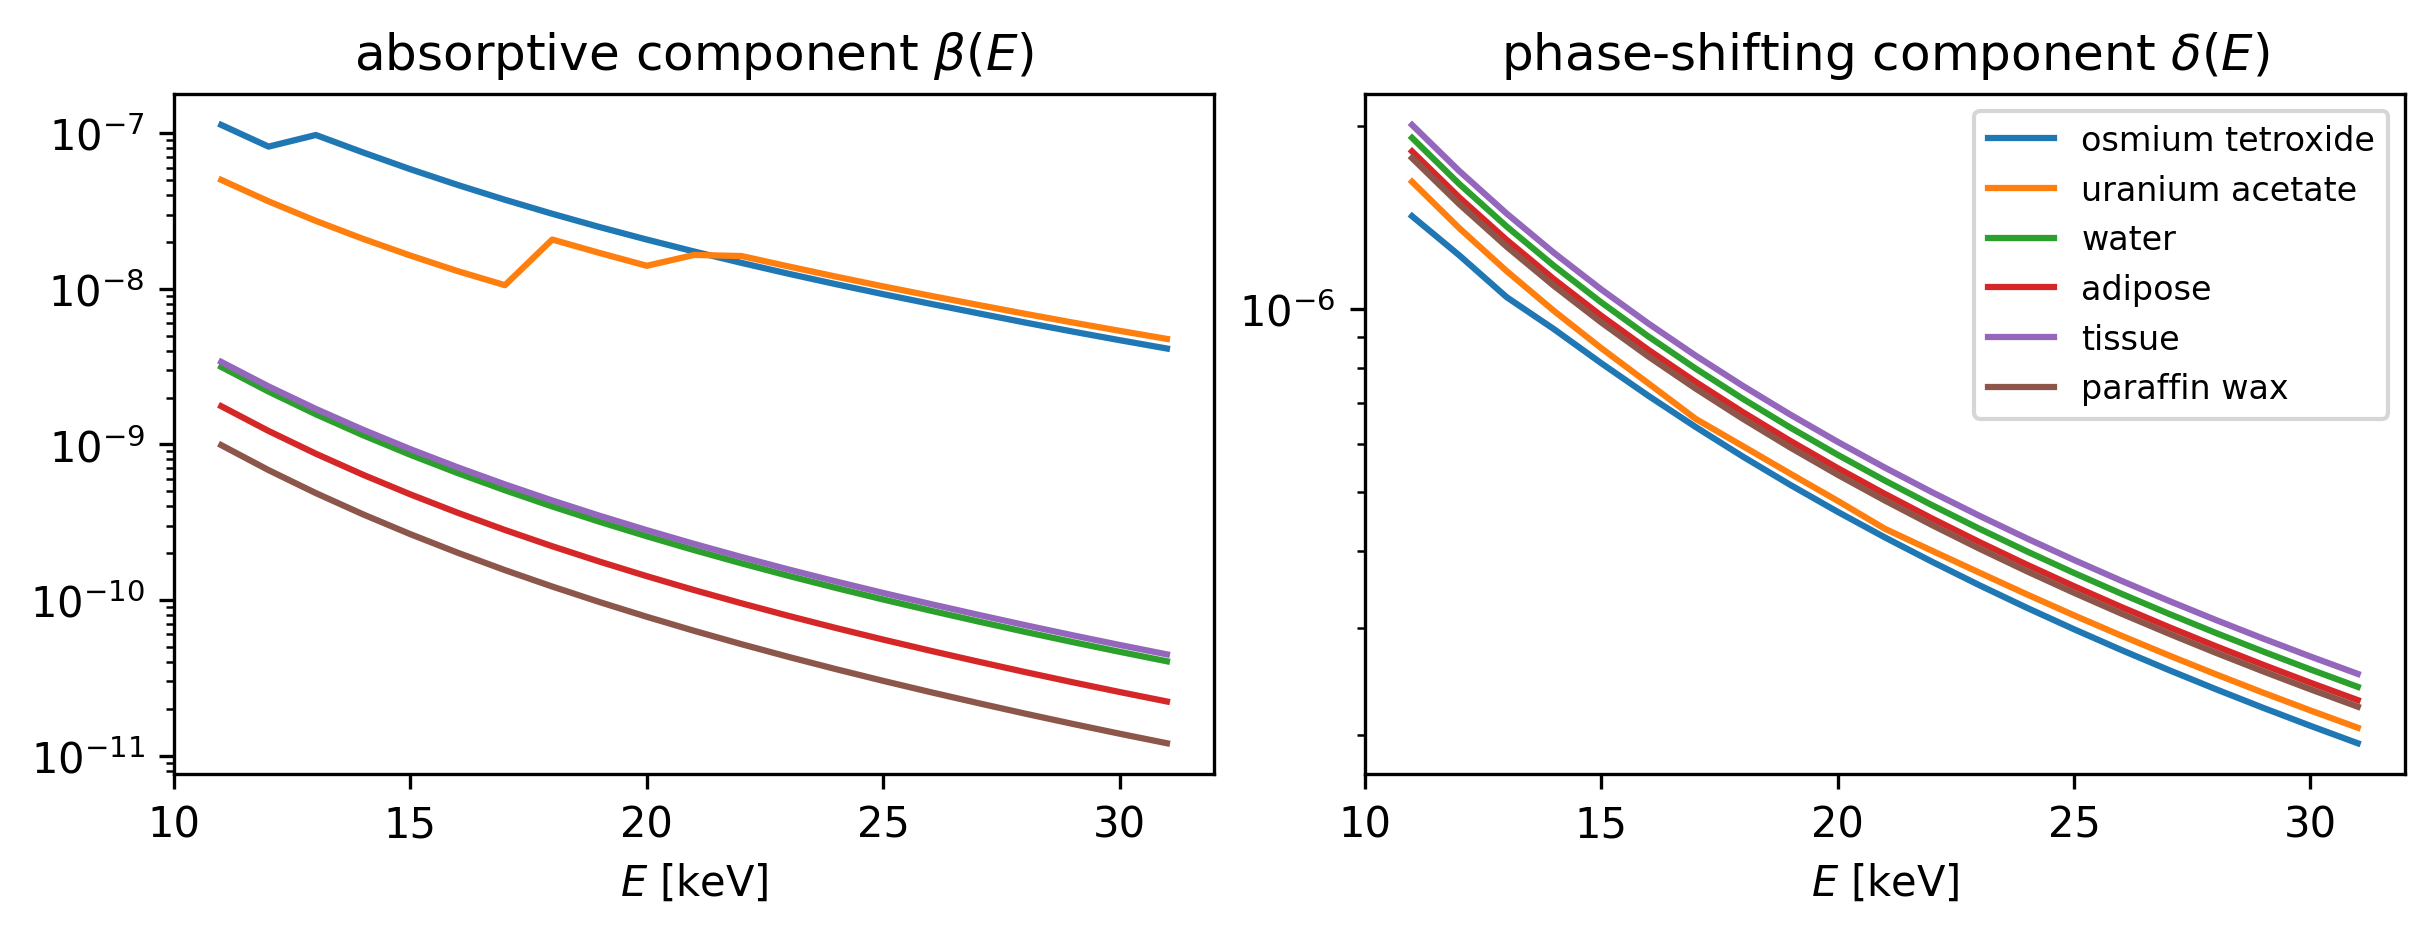

In [11]:
energy_range = np.arange(11, 32)
fig, ax = plt.subplots(1, 2, layout='constrained', dpi=300, figsize=[8,3])
for mat in [OsO4_01, UA_01, Water, Adipose, Tissue, Wax]:
    d, b = mat.delta_beta(energy_range)
    ax[0].plot(energy_range, b)
    ax[1].plot(energy_range, d, label=mat.name)
for i, axi in enumerate(ax):
    axi.set_title([r'absorptive component $\beta(E)$', 
                   r'phase-shifting component $\delta(E)$'][i])
    axi.set_xlabel(r'$E$ [keV]')
    axi.set_yscale('log')
ax[1].legend(fontsize=8)
plt.show()

In [ ]:
%%time

########################################

# Parameters

propdist = 50e-3
I0_per_um2 = 1e3

phantom = up_fish
dx = 0.2e-6
Nx, _ = phantom.shape
fov = dx * Nx

thickness = 2.5e-3

matdict = {
    1:  Water,
    # 12: Adipose,
    # 13: Tissue
    12: OsO4_01, 
    13: UA_01   
}

det_fov = fov
det_dx = 0.6e-6
det_Nx = int(det_fov / det_dx)

det_fwhm = 1.1e-6
det_psf = 'lorentzian'

I0_per_px = I0_per_um2 * (1e6 * det_dx)**2

energy = 24
wavelen = get_wavelen(energy)

db_phantom = jnp.array(label_to_db_phantom(up_fish, matdict, energy))

N_pad = 8
cval = 1
n_medium = 1 + 0j  # vacuum
key = jax.random.PRNGKey(3)  # noise

det_resample_func = init_plane_resample(
    (det_Nx, det_Nx), (det_dx, det_dx), resampling_method='linear'
)

def detect_field(field, dc=8):
    img = field.intensity.squeeze() 
    img = det_resample_func(img[...,None,None], field.dx.ravel()[:1])[...,0,0]
    img = apply_psf(img, det_dx, fwhm=det_fwhm, psf=det_psf)
    img = img[dc:-dc, dc:-dc]
    return img

Nz = 1  
dz = thickness / Nz
    
########################################

# Slice phantom ``sashimi'' style.
obj_beta =  jnp.stack([db_phantom[:,:,0]] * Nz, axis=0)
obj_delta = jnp.stack([db_phantom[:,:,1]] * Nz, axis=0)

# Make incident wave
field = cx.plane_wave(
    shape = (Nx, Nx),
    dx = dx,
    spectrum = wavelen,
    spectral_density = 1
) 
field = field * ((det_Nx / Nx)**2 / field.intensity.max())**0.5  # normalize to detector pixel


### Modulate thru object
# 1. PROJ. APPROX.
exit_field_PA = cx.thin_sample(
    field, 
    thickness * db_phantom[:,:,0][None,..., None,None],
    thickness * db_phantom[:,:,1][None,..., None,None], 1
)
det_field_PA = cx.transfer_propagate(exit_field_PA, propdist, n_medium, N_pad, cval=cval, mode='same')
img_PA = detect_field(det_field_PA)   
    
imshow_and_roi(img_PA, p=0.1, kw={'vmin':0, 'vmax':1.5, 'cmap':'bwr'})


In [ ]:
%%time

########################################

# Parameters

propdist = 50e-3
I0_per_um2 = 1e3

phantom = up_fish
dx = 0.2e-6
Nx, _ = phantom.shape
fov = dx * Nx

thickness = 2.5e-3

matdict = {
    1:  Water,
    # 12: Adipose,
    # 13: Tissue
    12: OsO4_01, 
    13: UA_01   
}

det_fov = fov
det_dx = 0.6e-6
det_Nx = int(det_fov / det_dx)

det_fwhm = 1.1e-6
det_psf = 'lorentzian'

I0_per_px = I0_per_um2 * (1e6 * det_dx)**2

energy = 24
wavelen = get_wavelen(energy)

db_phantom = jnp.array(label_to_db_phantom(up_fish, matdict, energy))

N_pad = 8
cval = 1
n_medium = 1 + 0j  # vacuum
key = jax.random.PRNGKey(3)  # noise

det_resample_func = init_plane_resample(
    (det_Nx, det_Nx), (det_dx, det_dx), resampling_method='linear'
)

def detect_field(field, dc=8):
    img = field.intensity.squeeze() 
    img = det_resample_func(img[...,None,None], field.dx.ravel()[:1])[...,0,0]
    img = apply_psf(img, det_dx, fwhm=det_fwhm, psf=det_psf)
    img = img[dc:-dc, dc:-dc]
    return img

ims = []
Nz_all = np.arange(1, 20)  #[1, 8, 16, 32]
for Nz in [1, 2, 4, 8]: #Nz_all:
    
    dz = thickness / Nz
    
    ########################################
    
    # Slice phantom ``sashimi'' style.
    obj_beta =  jnp.stack([db_phantom[:,:,0]] * Nz, axis=0)
    obj_delta = jnp.stack([db_phantom[:,:,1]] * Nz, axis=0)
    
    # Make incident wave
    field = cx.plane_wave(
        shape = (Nx, Nx),
        dx = dx,
        spectrum = wavelen,
        spectral_density = 1
    ) 
    field = field * ((det_Nx / Nx)**2 / field.intensity.max())**0.5  # normalize to detector pixel


    ### Modulate thru object
    # 1. PROJ. APPROX.
    exit_field_PA = cx.thin_sample(
        field, 
        thickness * db_phantom[:,:,0][None,..., None,None],
        thickness * db_phantom[:,:,1][None,..., None,None], 1
    )
    det_field_PA = cx.transfer_propagate(exit_field_PA, propdist, n_medium, N_pad, cval=cval, mode='same')
    img_PA = detect_field(det_field_PA)
        
    # 2. MULTISLICE
    propagator_transfer = cx.compute_transfer_propagator(
        pad(field, N_pad, cval=cval), dz, n_medium
    )
    exit_field = cx.multislice_thick_sample(field, obj_beta, obj_delta, n_medium, dz, N_pad, \
        propagator=propagator_transfer, reverse_propagate_distance=0
    )  
    
    # Propagate thru free space
    det_field = cx.transfer_propagate(exit_field, propdist, n_medium, N_pad, cval=cval, mode='same')
    
    # Detect
    img = detect_field(det_field)

    ########################################

    # kw = {'vmin':0.65, 'vmax':1.25}
    # imshow_and_roi(img, kw=kw)
    # imshow_and_roi(img_PA, kw=kw)

    diff = img_PA - img
    vm = np.max(np.abs(diff))
    imshow_and_roi(diff, kw={'cmap':'bwr','vmin':-vm, 'vmax':vm}, p=0.2)

    ims.append(img)




# Simulate CT scans

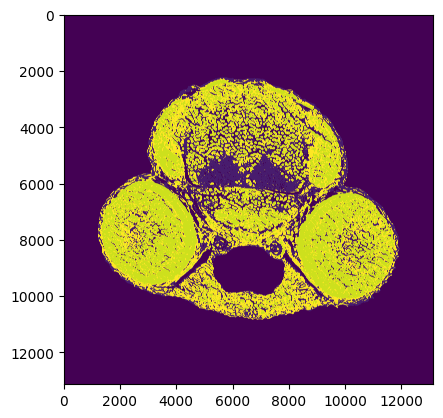

CPU times: user 9.39 s, sys: 4.98 s, total: 14.4 s
Wall time: 14.8 s


((13130, 13130), (11130, 11130))

In [16]:
%%time

# For CT sim, fish will be rotated; need to pad to make sure it stays in FOV. 

pad_up_fish = np.pad(up_fish, 1000, mode='constant', constant_values=0)
plt.imshow(pad_up_fish)
plt.show()

pad_up_fish.shape, up_fish.shape

In [29]:
# Fixed params 

propdist = 50e-3 

det_dx = 0.6e-6
tot_theta = jnp.pi  

ignore_bg = True

# define materials AND energy (higher with metal stains to avoid photon starvation)
matdicts = {
    'unstained': [{0: Wax, 1: Water, 12: Adipose, 13: Tissue}, 14],
    'stained':   [{0: Wax, 1: Water, 12: OsO4_01, 13: UA_01},  24]
}

phantom = pad_up_fish  # !! Make sure sufficiently padded to stay in FOV always !!
dx = 0.2e-6
Nx, _ = phantom.shape
fov = dx * Nx

N_theta = int((np.pi / 2) * (fov / det_dx))  # choose to satisfy Nyquist
thetas = jnp.linspace(0, tot_theta*(1-1/N_theta), N_theta)

### TESTING!!!
thetas = thetas[:5]

Nv = 400  # vertical stacking for CT

Nz = int(fov*1e4)  # multislice  -- roughly one slice per 0.1 mm
thickness = fov
dz = thickness / Nz

det_fov = fov

det_fwhm = None  
det_psf = 'lorentzian'

N_pad = 64
cval = 1
n_medium = 1 + 0j  # vacuum

# for rotation
base_grid = image_homogeneous_grid_from_shape(
    phantom.shape,
    dtype=jnp.float32
)

########################################

# Detector variables:
det_Nx = int(det_fov / det_dx)
det_Nv = int(Nv * dx / det_dx)

det_resample_func = init_plane_resample(
    (det_Nv, det_Nx), (det_dx, det_dx), resampling_method='linear'
)

def detect_field(field, nrows=1, dc=20): 
    img = field.intensity.squeeze() 
    img = det_resample_func(img[...,None,None], field.dx.ravel()[:1])[...,0,0]
    img = apply_psf(img, det_dx, fwhm=det_fwhm, psf=det_psf)
    if nrows is not None:
        v1 = int((img.shape[0] - nrows) / 2)
        v2 = v1 + nrows
        img = img[v1:v2, dc:-dc]
    return img 


In [26]:
%%time 
outd_main = 'outputs_v2/'
matdict_ids = ['stained', 'unstained'] 
N_print = 1  #20

for matdict_id in matdict_ids:
    
    outd = outd_main+f'{matdict_id}/'
    for subd in ['pa_z0', 'pa', 'ms_z0', 'ms']:
        os.makedirs(outd+subd, exist_ok=True)
        
    def save_arr(M, fname, outd=outd, dtype=np.float32):
        fname = fname + f'_{M.shape[0]}_{M.shape[1]}.bin'
        np.array(M, dtype=dtype).tofile(outd + fname)
    
    matdict, energy = matdicts[matdict_id]  # unpack materials

    wavelen = get_wavelen(energy)
    
    if ignore_bg:
        d_bg, b_bg = 0, 0   # background fill values during rotation
    else: 
        d_bg, b_bg = matdict[0].delta_beta(energy)  
    
    db_phantom = jnp.array(
        label_to_db_phantom(phantom, matdict, energy, skip_zero=ignore_bg)  # T/F for wax
    )

    ########################################

    # Uniform incident wave:
    field = cx.plane_wave(
        shape = (Nv, Nx),
        dx = dx,
        spectrum = wavelen,
        spectral_density = 1
    ) 
    field = field * ((det_Nx / Nx) * (det_Nv / Nv) / field.intensity.max())**0.5  

    # Multislice propagator
    propagator_transfer = cx.compute_transfer_propagator(
        pad(field, N_pad, cval=cval), dz, n_medium
    )

    ########################################

    t0 = time()
    
    for ind, angle in enumerate(thetas):
        
        # Slice & rotate to angle
        slice_beta = rotate_image_from_grid(db_phantom[:,:,0], base_grid, angle, cval=b_bg)
        slice_delta = rotate_image_from_grid(db_phantom[:,:,1], base_grid, angle, cval=d_bg)
    
        # Collapse phantom into projed z-slices (shape ~ Nz, Nx)
        proj_beta_slices = segment_project_slices(slice_beta, Nz, dx)    
        proj_delta_slices = segment_project_slices(slice_delta, Nz, dx)  
    
        
        ### 1. PROJ. APPROX.
        
        # Sum over slices & stack vertically (shape ~ Nv, Nx to match field)
        proj_beta = jnp.stack([jnp.sum(proj_beta_slices, axis=0)] * Nv, axis=0)
        proj_delta = jnp.stack([jnp.sum(proj_delta_slices, axis=0)] * Nv, axis=0)
    
        exit_field_PA = cx.thin_sample(
            field, proj_beta[None,..., None,None], proj_delta[None,..., None,None], 1
        )
        img_PA_z0 = detect_field(exit_field_PA)

        det_field_PA = cx.transfer_propagate(
            exit_field_PA, propdist, n_medium, N_pad, cval=cval, mode='same'
        )
        img_PA = detect_field(det_field_PA)
    
        
        ### 2. MULTISLICE
        
        # Stack slices vertically (shape ~ Nz, Nv, Nx to match multislice field batch)
        obj_beta = jnp.stack([proj_beta_slices] * Nv, axis=1)  # note, different axis than PA!
        obj_delta = jnp.stack([proj_delta_slices] * Nv, axis=1)
    
        exit_field = cx.multislice_thick_sample(field, obj_beta, obj_delta, n_medium, 1, N_pad, 
            propagator=propagator_transfer, reverse_propagate_distance=0
        )  
        img_z0 = detect_field(exit_field)

        det_field = cx.transfer_propagate(
            exit_field, propdist, n_medium, N_pad, cval=cval, mode='same'
        )
        img = detect_field(det_field)

        ### Save outputs
        
        fid = f'angle_{ind:04}'

        save_arr(img_PA_z0, f'pa_z0/{fid}')
        save_arr(img_PA, f'pa/{fid}')
        save_arr(img_z0, f'ms_z0/{fid}')
        save_arr(img, f'ms/{fid}')

        ### Check outputs
    
        if (ind % N_print == 0):
            print(f'{ind:4} --- {angle * 180 / np.pi:5.2f} deg --- {time() - t0:4.1f} s')
            t0 = time()
            
        # for M in [img, img_PA]:
        #     fig, ax = plt.subplots(figsize=[10,1.3], dpi=300)
        #     plt.imshow(M, aspect='auto', vmin=0, vmax=1.1)
        #     plt.colorbar()
        #     plt.show()
        
        # fig, ax = plt.subplots(figsize=[10,1.3], dpi=300)
        # diff = img-img_PA
        # vm = np.max(np.abs(diff))
        # plt.imshow(diff, aspect='auto', vmin=-vm, vmax=vm, cmap='bwr')
        # plt.colorbar()
        # plt.show()

   0 ---  0.00 deg ---  9.0 s
   1 ---  0.03 deg ---  6.4 s
   2 ---  0.05 deg ---  6.5 s
   3 ---  0.08 deg ---  6.4 s
   4 ---  0.10 deg ---  6.3 s
   5 ---  0.13 deg ---  6.6 s
   6 ---  0.16 deg ---  6.4 s
   7 ---  0.18 deg ---  6.4 s
   8 ---  0.21 deg ---  6.4 s
   9 ---  0.24 deg ---  6.6 s
  10 ---  0.26 deg ---  6.3 s
  11 ---  0.29 deg ---  6.6 s
  12 ---  0.31 deg ---  6.2 s
CPU times: user 5min 19s, sys: 2min 47s, total: 8min 7s
Wall time: 1min 32s


KeyboardInterrupt: 

In [30]:
thetas.size

5